In [2]:
from PIL import Image
import torch
import numpy as np
from celeb_a_mask_hq import LABEL_COLORS, integer_mask_to_pil

In [3]:
# Load the image
mask_image_path = "./test-masks/mask_pred0.jpeg"
mask_image = Image.open(mask_image_path).convert("RGB")
print(f"Loaded image size: {mask_image.size}")

Loaded image size: (1024, 1024)


In [4]:
# Convert image to torch tensor
# Shape: (H, W, 3)
image_tensor = torch.from_numpy(np.array(mask_image)).float()
H, W, C = image_tensor.shape

# Convert label colors to tensor
# Shape: (N, 3)
label_colors_tensor = torch.tensor(LABEL_COLORS).float()

print(f"Image tensor shape: {image_tensor.shape}")
print(f"Label colors tensor shape: {label_colors_tensor.shape}")

Image tensor shape: torch.Size([1024, 1024, 3])
Label colors tensor shape: torch.Size([19, 3])


In [5]:
# Flatten image to (H*W, 3) for distance calculation
flat_image = image_tensor.reshape(-1, 3)

# Calculate Euclidean distance between each pixel and each label color
# flat_image: (H*W, 3)
# label_colors_tensor: (N, 3)
# dists result: (H*W, N)
dists = torch.cdist(flat_image, label_colors_tensor)

# Find the index of the minimum distance for each pixel (the nearest label)
nearest_label_indices = torch.argmin(dists, dim=1)

# Reshape back to (H, W) to get the integer mask
integer_mask = nearest_label_indices.reshape(H, W).to(torch.uint8)

print(f"Integer mask shape: {integer_mask.shape}")
print(f"Found unique labels: {torch.unique(integer_mask).tolist()}")

Integer mask shape: torch.Size([1024, 1024])
Found unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


Saved reconstructed mask to reconstructed_mask.png


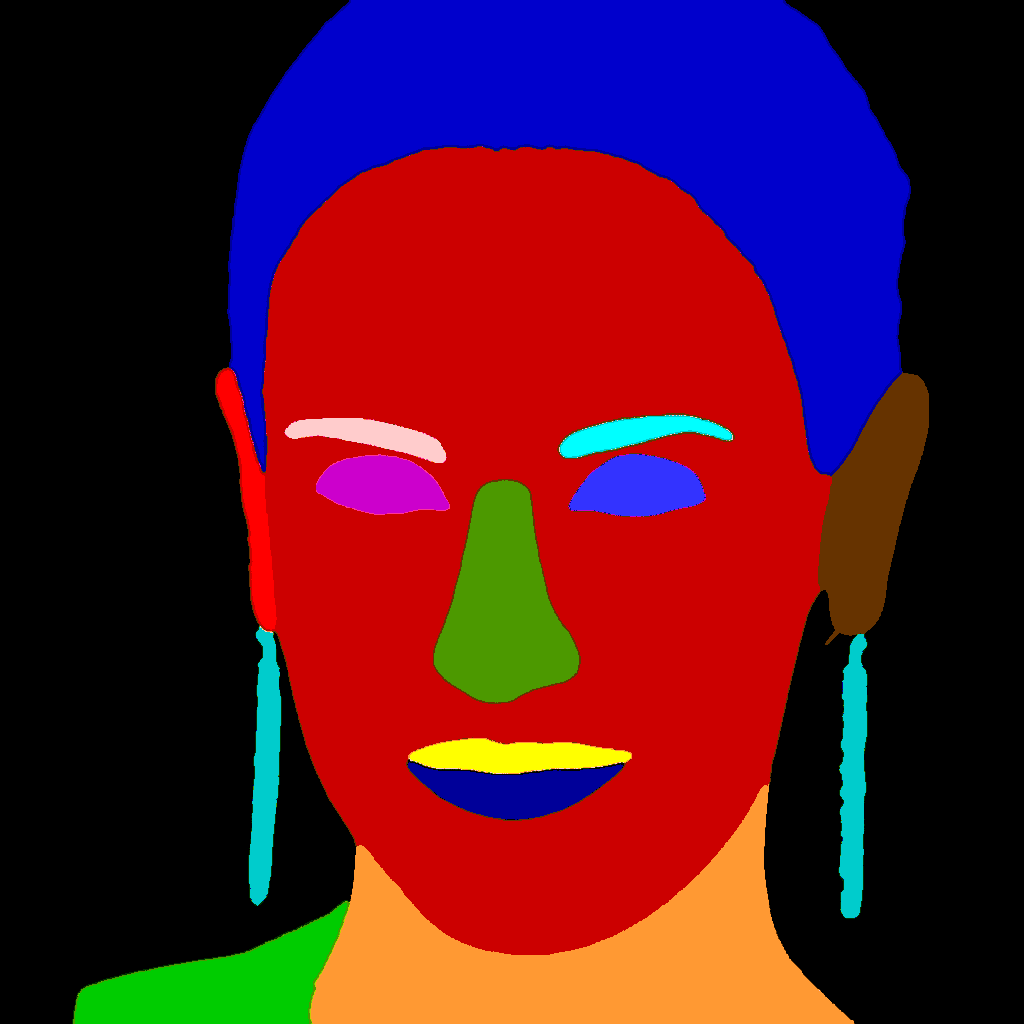

In [6]:
# Convert the integer mask back to a palette-based PIL image using the helper function
reconstructed_mask = integer_mask_to_pil(integer_mask)

# Save or display the result
output_path = "reconstructed_mask.png"
reconstructed_mask.save(output_path)
print(f"Saved reconstructed mask to {output_path}")

# Display the image (if running in a notebook interface)
display(reconstructed_mask)